In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv("../../data/final_train_data/player_data.csv", index_col=False)

In [ ]:
df_match = pd. read_csv("../../data/final_train_data/match.csv")

In [ ]:
import pandas as pd
import numpy as np

# -----------------------------
# Hyperparameters (easy to tune)
# -----------------------------
ALPHA = 1.3  # weight sharpness

N_SELECT = {
    "FW": 4,
    "MF": 4,
    "DF": 4,
    "GK": 2
}

# -----------------------------
# Selection score
# -----------------------------
df["selection_score"] = (
    0.6 * df["overall_rating"] +
    0.4 * df["base_stats"]
)

# -----------------------------
# Helper: weighted mean
# -----------------------------
def weighted_mean(values, weights):
    return np.sum(values * weights)

# -----------------------------
# Stat formulas (vectorized)
# -----------------------------
def attacking_score(d):
    return (
        0.25 * d["finishing"] +
        0.20 * d["shot_power"] +
        0.20 * d["attack_position"] +
        0.20 * d["ball_control"] +
        0.15 * d["short_passing"]
    )

def defensive_score(d):
    return (
        0.35 * d["defensive_awareness"] +
        0.30 * d["standing_tackle"] +
        0.20 * d["interceptions"] +
        0.15 * d["strength"]
    )

def gk_score(d):
    return (
        0.30 * d["gk_reflexes"] +
        0.25 * d["gk_diving"] +
        0.20 * d["gk_positioning"] +
        0.15 * d["gk_handling"] +
        0.10 * d["reactions"]
    )

def physical_score(d):
    return (
        0.30 * d["sprint_speed"] +
        0.25 * d["acceleration"] +
        0.25 * d["stamina"] +
        0.20 * d["balance"]
    )

# -----------------------------
# Main aggregation
# -----------------------------
team_rows = []

group_keys = ["team", "roster_date"]

for (team, roster_date), g in df.groupby(group_keys):

    selected_players = []

    # ---- player selection per position ----
    for pos, n in N_SELECT.items():
        pos_players = (
            g[g["general_position"] == pos]
            .sort_values("selection_score", ascending=False)
            .head(n)
        )
        if len(pos_players) < n:
            break  # skip incomplete rosters
        selected_players.append(pos_players)

    if len(selected_players) != 4:
        continue

    roster = pd.concat(selected_players)

    # ---- compute position-normalized weights ----
    roster["weight"] = 0.0

    for pos in N_SELECT.keys():
        mask = roster["general_position"] == pos
        scores = roster.loc[mask, "selection_score"] ** ALPHA
        roster.loc[mask, "weight"] = scores / scores.sum()

    # ---- compute individual component scores ----
    roster["A"] = attacking_score(roster)
    roster["D"] = defensive_score(roster)
    roster["G"] = gk_score(roster)
    roster["P"] = physical_score(roster)

    # ---- position-level aggregation ----
    A_FW = weighted_mean(
        roster.loc[roster.general_position == "FW", "A"],
        roster.loc[roster.general_position == "FW", "weight"]
    )
    A_MF = weighted_mean(
        roster.loc[roster.general_position == "MF", "A"],
        roster.loc[roster.general_position == "MF", "weight"]
    )

    D_DF = weighted_mean(
        roster.loc[roster.general_position == "DF", "D"],
        roster.loc[roster.general_position == "DF", "weight"]
    )
    D_MF = weighted_mean(
        roster.loc[roster.general_position == "MF", "D"],
        roster.loc[roster.general_position == "MF", "weight"]
    )

    G_team = weighted_mean(
        roster.loc[roster.general_position == "GK", "G"],
        roster.loc[roster.general_position == "GK", "weight"]
    )

    P_team = weighted_mean(
        roster.loc[roster.general_position != "GK", "P"],
        roster.loc[roster.general_position != "GK", "weight"]
    )

    # ---- team-level scores ----
    A_team = 0.6 * A_FW + 0.4 * A_MF
    D_team = 0.7 * D_DF + 0.3 * D_MF

    T_overall = (
        0.35 * A_team +
        0.30 * D_team +
        0.20 * G_team +
        0.15 * P_team
    )

    team_rows.append({
        "team": team,
        "roster_date": roster_date,
        "attack": A_team,
        "defense": D_team,
        "goalkeeping": G_team,
        "physical": P_team,
        "team_overall": T_overall
    })

# -----------------------------
# Final team-level DataFrame
# -----------------------------
team_stats_df = pd.DataFrame(team_rows)

In [ ]:
import warnings
warnings.filterwarnings("ignore")


# Import merge module
import sys
sys.path.append('../merge')
from merge import merge_match_with_team_stats

# Merge match data with team statistics
df_match_enriched = merge_match_with_team_stats(df_match, team_stats_df, verbose=True)

In [21]:
# Create home_team_win column: 1 for home win, 0.5 for draw, 0 for away win
# Note: This column is named 'home_team_win' (not 'home_team_wins') to match training.py expectations
df_match_enriched['home_team_win'] = np.where(
    df_match_enriched['home_score'] > df_match_enriched['away_score'], 1,
    np.where(df_match_enriched['home_score'] == df_match_enriched['away_score'], 0.5, 0)
)

In [22]:
# Import training functions
import sys
sys.path.append('../train')
from training import train_all_models

# Define feature columns for training
feature_cols = [
    'home_attack', 'home_defense', 'home_goalkeeping', 'home_physical', 'home_team_overall',
    'away_attack', 'away_defense', 'away_goalkeeping', 'away_physical', 'away_team_overall'
]

# Train all models and get results
training_results = train_all_models(
    df_match_enriched, 
    feature_cols,
    test_size=0.2,
    random_state=42
)

# Access individual results
print("\n" + "="*50)
print("TRAINING COMPLETE")
print("="*50)
print("\nModel Comparison:")
print(training_results['comparison'])

# Get the best model
best_model_name = training_results['comparison'].iloc[0]['Model']
best_model = training_results['results'][best_model_name]['model']
print(f"\nBest Model: {best_model_name}")

Binary Classification - Class distribution:
  Away wins: 440
  Home wins: 704
  Total matches (excluding draws): 1144
  Draws excluded: 425

Training set: 915 samples
Test set: 229 samples

LOGISTIC REGRESSION
Accuracy: 0.6550

Classification Report:
              precision    recall  f1-score   support

    Away Win       0.58      0.38      0.46        88
    Home Win       0.68      0.83      0.75       141

    accuracy                           0.66       229
   macro avg       0.63      0.60      0.60       229
weighted avg       0.64      0.66      0.64       229


Confusion Matrix:
[[ 33  55]
 [ 24 117]]

RANDOM FOREST
Accuracy: 0.6157

Classification Report:
              precision    recall  f1-score   support

    away_win       0.50      0.47      0.48        88
    home_win       0.68      0.71      0.69       141

    accuracy                           0.62       229
   macro avg       0.59      0.59      0.59       229
weighted avg       0.61      0.62      0.61       22

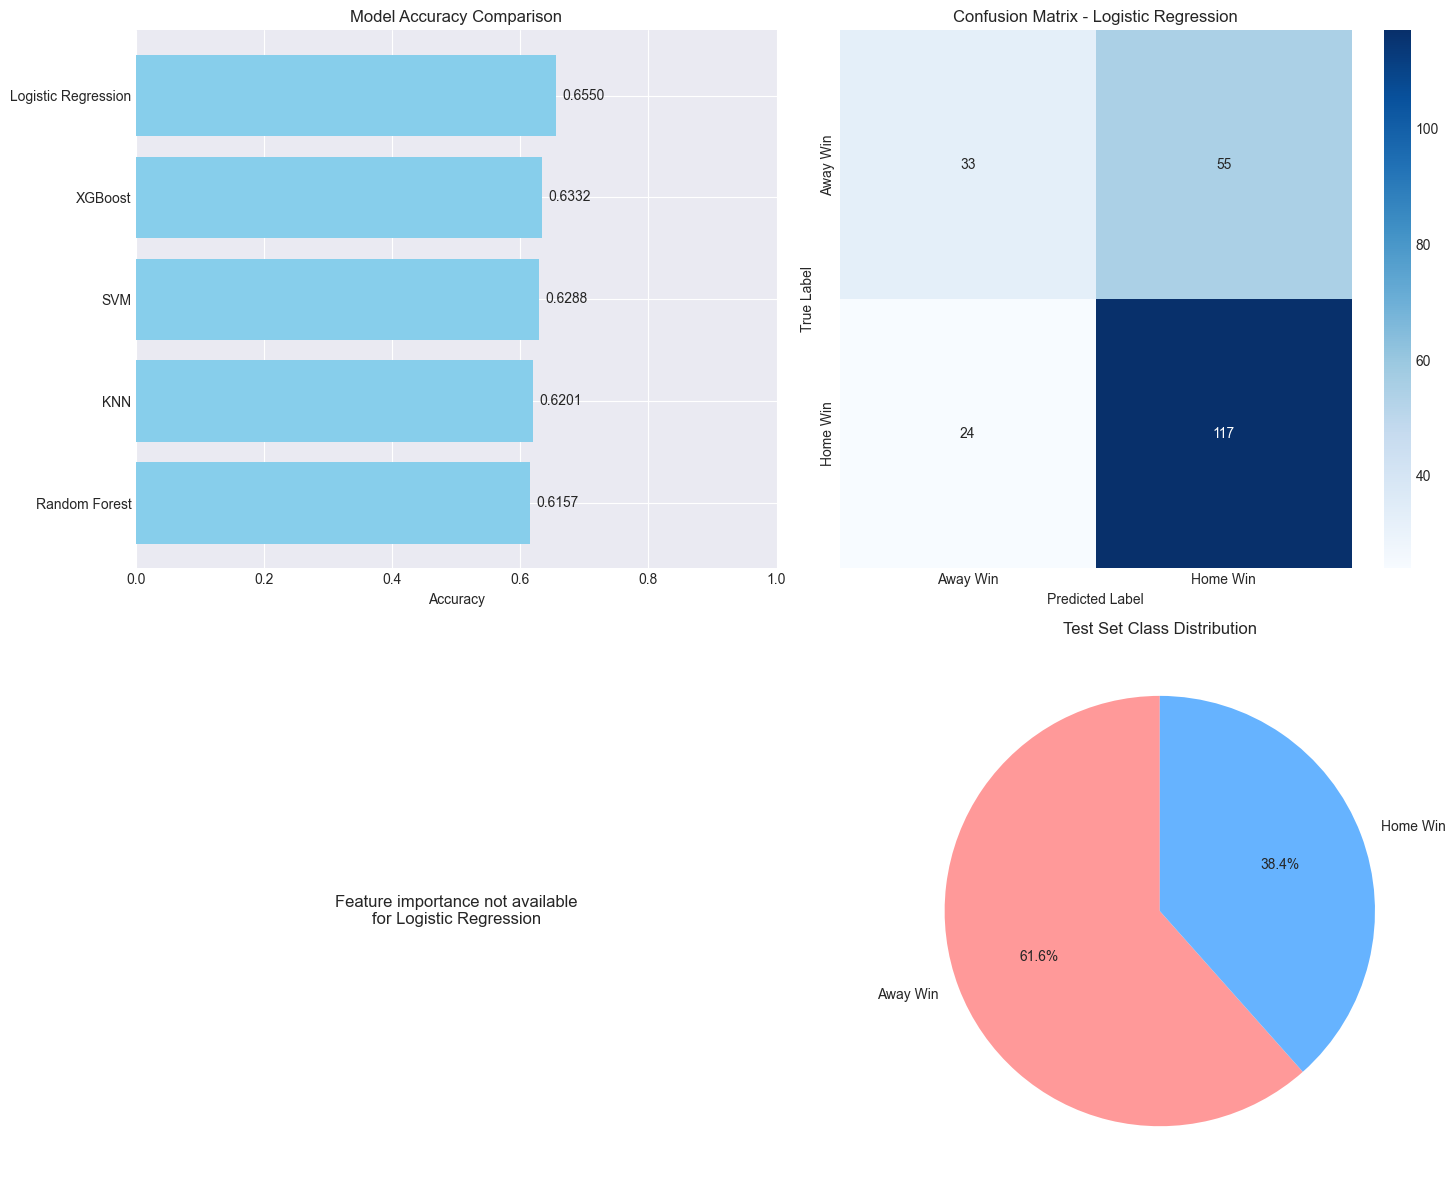


📊 Visualization complete!


In [23]:
# Visualize model comparison
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Create figure with subplots
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Model Accuracy Comparison
ax1 = axes[0, 0]
comparison_df = training_results['comparison'].sort_values('Accuracy', ascending=True)
ax1.barh(comparison_df['Model'], comparison_df['Accuracy'], color='skyblue')
ax1.set_xlabel('Accuracy')
ax1.set_title('Model Accuracy Comparison')
ax1.set_xlim([0, 1])
for i, v in enumerate(comparison_df['Accuracy']):
    ax1.text(v + 0.01, i, f'{v:.4f}', va='center')

# 2. Confusion Matrix for Best Model
from sklearn.metrics import confusion_matrix
ax2 = axes[0, 1]
X_test, y_test = training_results['test_data']
y_pred = training_results['results'][best_model_name]['predictions']
cm = confusion_matrix(y_test, y_pred, labels=['away_win', 'home_win'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax2,
            xticklabels=['Away Win', 'Home Win'],
            yticklabels=['Away Win', 'Home Win'])
ax2.set_title(f'Confusion Matrix - {best_model_name}')
ax2.set_ylabel('True Label')
ax2.set_xlabel('Predicted Label')

# 3. Feature Importance (if available)
ax3 = axes[1, 0]
if best_model_name in ['Random Forest', 'XGBoost']:
    feature_importance = pd.DataFrame({
        'feature': feature_cols,
        'importance': training_results['results'][best_model_name]['model'].feature_importances_
    }).sort_values('importance', ascending=True)
    
    ax3.barh(feature_importance['feature'], feature_importance['importance'], color='lightgreen')
    ax3.set_xlabel('Importance')
    ax3.set_title(f'Feature Importance - {best_model_name}')
else:
    ax3.text(0.5, 0.5, f'Feature importance not available\nfor {best_model_name}',
             ha='center', va='center', fontsize=12)
    ax3.set_xlim([0, 1])
    ax3.set_ylim([0, 1])
    ax3.axis('off')

# 4. Class Distribution
ax4 = axes[1, 1]
class_counts = y_test.value_counts()
colors = ['#ff9999', '#66b3ff']
ax4.pie(class_counts, labels=['Away Win', 'Home Win'], autopct='%1.1f%%',
        startangle=90, colors=colors)
ax4.set_title('Test Set Class Distribution')

plt.tight_layout()
plt.show()

print("\n📊 Visualization complete!")

In [26]:
from sklearn.model_selection import cross_val_score

# Prepare full dataset for cross-validation
df_train = df_match_enriched.dropna(subset=['home_team_win'])
X = df_train[feature_cols]
y_continuous = df_train['home_team_win']

# Convert to binary classification: exclude draws
binary_mask = (y_continuous == 0.0) | (y_continuous == 1.0)
X_binary = X[binary_mask]
y_binary = ['away_win' if x == 0.0 else 'home_win' for x in y_continuous[binary_mask]]

# Use the existing scaler
X_scaled = training_results['scaler'].transform(X_binary)

# Encode labels same way as training
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
le.fit(['away_win', 'home_win'])
y_encoded = le.transform(y_binary)

# Cross-validation for best model
cv_scores = cross_val_score(best_model, X_scaled, y_encoded, cv=5)
print(f"\n5-Fold CV Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")


5-Fold CV Accuracy: 0.6634 (+/- 0.0313)


In [27]:
# Save the best model and scaler
import joblib
import os

# Define model directory
model_dir = "/Users/lionlucky7/01.Projects/In-progress/soccer_prediction/2026_world_cup/training_models"
os.makedirs(model_dir, exist_ok=True)

# Create clean filename
model_filename = best_model_name.replace(' ', '_').lower()

# Save model, scaler, and feature columns
model_path = f"{model_dir}/{model_filename}_model.joblib"
scaler_path = f"{model_dir}/scaler.joblib"
features_path = f"{model_dir}/feature_columns.joblib"

joblib.dump(best_model, model_path)
joblib.dump(training_results['scaler'], scaler_path)
joblib.dump(feature_cols, features_path)

print("\n" + "="*50)
print("MODEL SAVED SUCCESSFULLY")
print("="*50)
print(f"✅ Model saved to: {model_path}")
print(f"✅ Scaler saved to: {scaler_path}")
print(f"✅ Feature columns saved to: {features_path}")
print(f"\n📊 Model: {best_model_name}")
print(f"📊 CV Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")


MODEL SAVED SUCCESSFULLY
✅ Model saved to: /Users/lionlucky7/01.Projects/In-progress/soccer_prediction/2026_world_cup/training_models/logistic_regression_model.joblib
✅ Scaler saved to: /Users/lionlucky7/01.Projects/In-progress/soccer_prediction/2026_world_cup/training_models/scaler.joblib
✅ Feature columns saved to: /Users/lionlucky7/01.Projects/In-progress/soccer_prediction/2026_world_cup/training_models/feature_columns.joblib

📊 Model: Logistic Regression
📊 CV Accuracy: 0.6634 (+/- 0.0313)
